In [32]:
import pandas as pd
import matplotlib.pyplot as plt

acc1 = pd.read_csv("../Human_Activity_Recognition/dataset/RawData/acc_exp01_user01.txt", 
                    sep=r'\s+', header=None, names=['acc_x', 'acc_y', 'acc_z'])
acc1.shape

(20598, 3)

In [33]:
acc1.head()

,acc_x,acc_y,acc_z
0,0.918056,-0.112500,0.509722
1,0.911111,-0.093056,0.537500
2,0.881944,-0.086111,0.513889
3,0.881944,-0.086111,0.513889
4,0.879167,-0.100000,0.505556


In [34]:
gyro1 = pd.read_csv("../Human_Activity_Recognition/dataset/RawData/gyro_exp01_user01.txt", sep=r'\s+', header=None, names=['gyro_x', 'gyro_y', 'gyro_z'])
gyro1.shape

(20598, 3)

In [35]:
gyro1.head()

,gyro_x,gyro_y,gyro_z
0,-0.054978,-0.069639,-0.030849
1,-0.012523,0.019242,-0.038485
2,-0.023518,0.276417,0.006414
3,-0.093462,0.367741,0.001222
4,-0.124311,0.476780,-0.022907


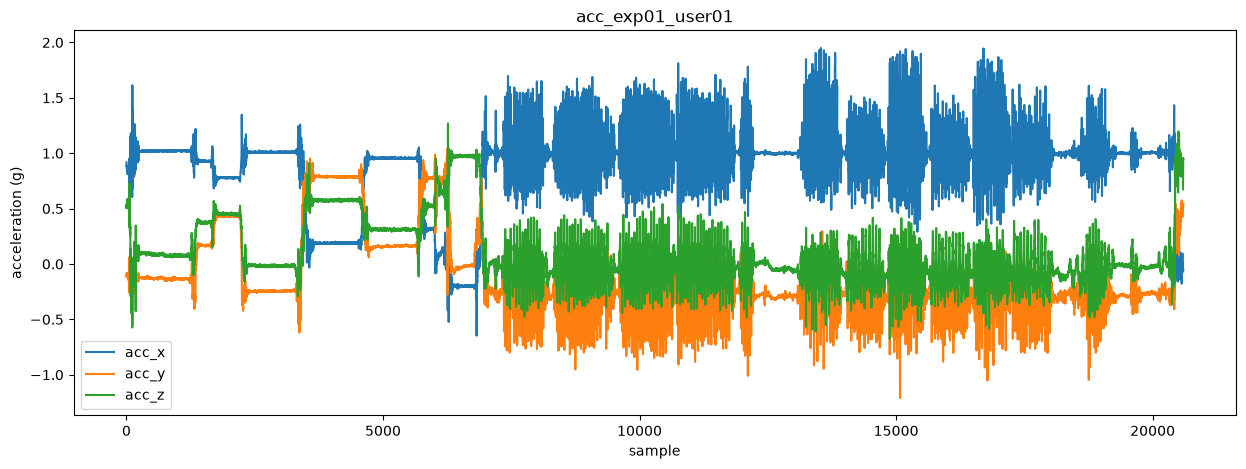

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(acc1['acc_x'], label='acc_x')
plt.plot(acc1['acc_y'], label='acc_y')
plt.plot(acc1['acc_z'], label='acc_z')
plt.legend()
plt.xlabel('sample')
plt.ylabel('acceleration (g)')
plt.title('acc_exp01_user01')
plt.show()

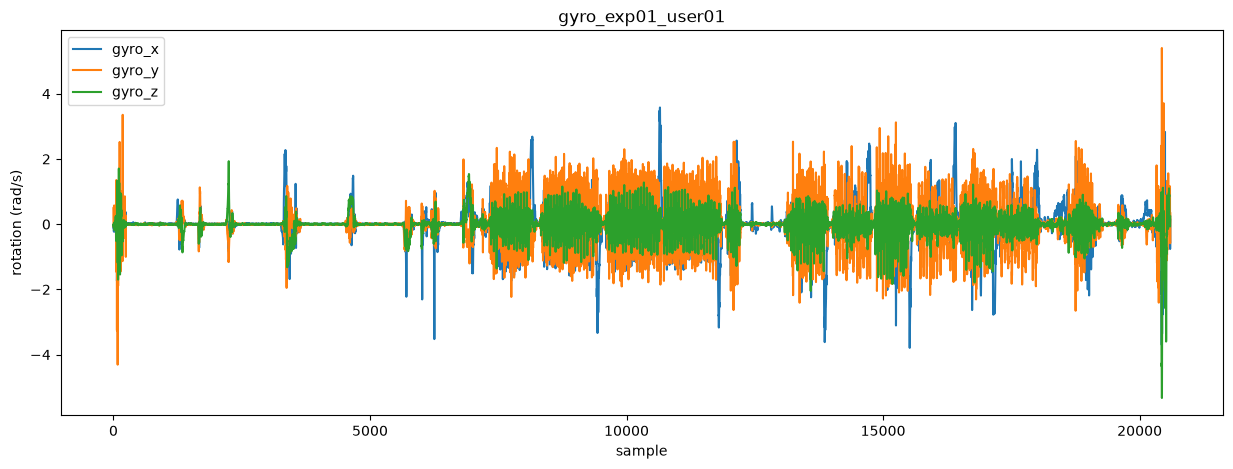

In [38]:
plt.figure(figsize=(15, 5))
plt.plot(gyro1['gyro_x'], label='gyro_x')
plt.plot(gyro1['gyro_y'], label='gyro_y')
plt.plot(gyro1['gyro_z'], label='gyro_z')
plt.legend()
plt.xlabel('sample')
plt.ylabel('rotation (rad/s)')
plt.title('gyro_exp01_user01')
plt.show()

In [ ]:
labels = pd.read_csv("../Human_Activity_Recognition/dataset/RawData/labels.txt", 
                    sep=r'\s+', header=None, 
                    names=['experiment_number_ID', 'user_number_ID', 'activity_number_ID', 'label_start_point', 'label_end_point'])
labels.shape


(1214, 5)

In [13]:
labels.head(-10)

,experiment_number_ID,user_number_ID,activity_number_ID,label_start_point,label_end_point
0,1,1,5,250,1232
1,1,1,7,1233,1392
2,1,1,4,1393,2194
3,1,1,8,2195,2359
4,1,1,5,2360,3374
...,...,...,...,...,...
1199,61,30,11,4198,4446
1200,61,30,6,4447,5657
1201,61,30,10,5658,5896
1202,61,30,4,5897,7165


In [6]:
activity_labels = pd.read_csv("../Human_Activity_Recognition/dataset/activity_labels.txt", 
                              sep=r'\s+', header=None, names=['activity_number_id', 'activity_label'])
activity_labels.shape

(12, 2)

In [7]:
activity_labels.head(12)

,activity_number_id,activity_label
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING
6,7,STAND_TO_SIT
7,8,SIT_TO_STAND
8,9,SIT_TO_LIE
9,10,LIE_TO_SIT


In [42]:
labels_acc1 = labels[labels['experiment_number_ID'] == 1] #how many labeled segments does experiment1 have
labels_acc1.head(30)

,experiment_number_ID,user_number_ID,activity_number_ID,label_start_point,label_end_point
0,1,1,5,250,1232
1,1,1,7,1233,1392
2,1,1,4,1393,2194
3,1,1,8,2195,2359
4,1,1,5,2360,3374
5,1,1,11,3375,3662
6,1,1,6,3663,4538
7,1,1,10,4539,4735
8,1,1,4,4736,5667
9,1,1,9,5668,5859


In [41]:
labels_gyro1 = labels[labels["experiment_number_ID"] == 1]
labels_gyro1.head(30)

,experiment_number_ID,user_number_ID,activity_number_ID,label_start_point,label_end_point
0,1,1,5,250,1232
1,1,1,7,1233,1392
2,1,1,4,1393,2194
3,1,1,8,2195,2359
4,1,1,5,2360,3374
5,1,1,11,3375,3662
6,1,1,6,3663,4538
7,1,1,10,4539,4735
8,1,1,4,4736,5667
9,1,1,9,5668,5859


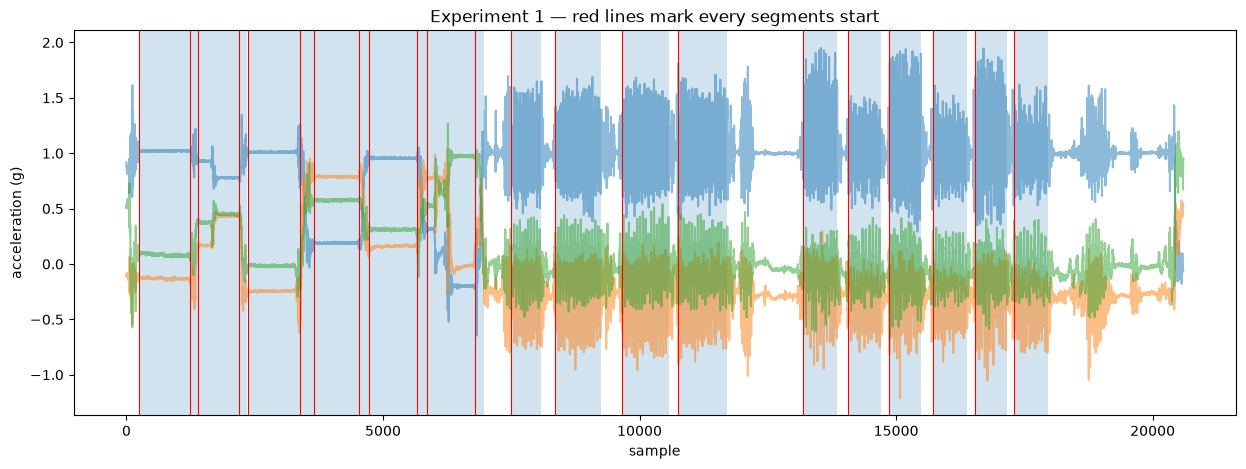

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(acc1['acc_x'], alpha=0.5)
plt.plot(acc1['acc_y'], alpha=0.5)
plt.plot(acc1['acc_z'], alpha=0.5)

for _, row in labels_acc1.iterrows():
    plt.axvspan(row['label_start_point'], row['label_end_point'], alpha=0.2)
    #draw a vertical line at the start of each segment
    plt.axvline(row['label_start_point'], color='red', linewidth=0.8)

plt.xlabel('sample')
plt.ylabel('acceleration (g)')
plt.title('Experiment 1 — red lines mark every segments start')
plt.show()

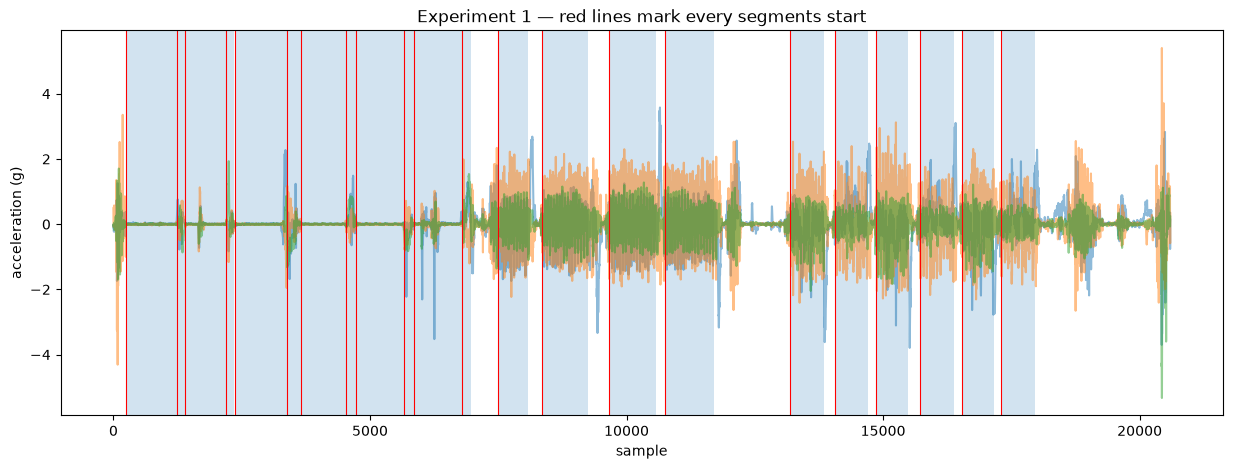

In [43]:
plt.figure(figsize=(15, 5))
plt.plot(gyro1['gyro_x'], alpha=0.5)
plt.plot(gyro1['gyro_y'], alpha=0.5)
plt.plot(gyro1['gyro_z'], alpha=0.5)

for _, row in labels_gyro1.iterrows():
    plt.axvspan(row['label_start_point'], row['label_end_point'], alpha=0.2)
    #draw a vertical line at the start of each segment
    plt.axvline(row['label_start_point'], color='red', linewidth=0.8)

plt.xlabel('sample')
plt.ylabel('acceleration (g)')
plt.title('Experiment 1 — red lines mark every segments start')
plt.show()

In [ ]:
WINDOW_SIZE = 128 #samples per window, 2.56 s at 50 Hz
STEP = 128 #how far we slide between windows, each window starts exactly where the last ended, no overlap

In [ ]:
segment = acc1.iloc[250:1233]
print(segment)

         acc_x     acc_y     acc_z
250   1.020833 -0.125000  0.105556
251   1.025000 -0.125000  0.101389
252   1.020833 -0.125000  0.104167
253   1.016667 -0.125000  0.108333
254   1.018056 -0.127778  0.108333
...        ...       ...       ...
1228  1.022222 -0.137500  0.077778
1229  1.025000 -0.137500  0.076389
1230  1.030556 -0.144444  0.079167
1231  1.016667 -0.143056  0.058333
1232  1.015278 -0.141667  0.059722

[983 rows x 3 columns]


In [25]:
windows = []
for start_idx in range(0, len(segment) - WINDOW_SIZE + 1, STEP):
  window = segment.iloc[start_idx : start_idx + WINDOW_SIZE]
  windows.append(window)

print(len(windows))
print(windows)

7
[        acc_x     acc_y     acc_z
250  1.020833 -0.125000  0.105556
251  1.025000 -0.125000  0.101389
252  1.020833 -0.125000  0.104167
253  1.016667 -0.125000  0.108333
254  1.018056 -0.127778  0.108333
..        ...       ...       ...
373  1.019445 -0.125000  0.098611
374  1.018056 -0.122222  0.101389
375  1.022222 -0.119444  0.094444
376  1.022222 -0.120833  0.087500
377  1.023611 -0.125000  0.091667

[128 rows x 3 columns],         acc_x     acc_y     acc_z
378  1.019445 -0.118056  0.104167
379  1.013889 -0.123611  0.098611
380  1.013889 -0.123611  0.098611
381  1.018056 -0.120833  0.084722
382  1.018056 -0.120833  0.084722
..        ...       ...       ...
501  1.022222 -0.134722  0.073611
502  1.022222 -0.127778  0.086111
503  1.022222 -0.131944  0.077778
504  1.019445 -0.129167  0.090278
505  1.018056 -0.127778  0.075000

[128 rows x 3 columns],         acc_x     acc_y     acc_z
506  1.022222 -0.126389  0.079167
507  1.022222 -0.130556  0.084722
508  1.020833 -0.134722  0.09

In [ ]:
all_windows = []  #will hold every window from every segment
all_labels  = []  #the activity id for each window (same length as all_windows)

#go through each labeled segment
for _, seg in labels_acc1.iterrows():
    start = seg['label_start_point']
    end = seg['label_end_point']
    activity = seg['activity_number_ID']

    segment = acc1.iloc[start:end+1] #slice the signal for this segment

    #window this segment
    for start_idx in range(0, len(segment) - WINDOW_SIZE + 1, STEP):
        window = segment.iloc[start_idx : start_idx + WINDOW_SIZE]
        all_windows.append(window)
        all_labels.append(activity) #tag this window with its activity

print("total windows:", len(all_windows))
print("total labels:", len(all_labels))

print(all_labels)
print(all_windows)

total windows: 98
total labels: 98
[np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(7), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(8), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(11), np.int64(11), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(10), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(12), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(3), np.int64(3), np.int64(3)